In [1]:
from conv_reproj import match
from align_and_diff import a_d
from header_setup import read

from matplotlib import pyplot as plt
import numpy as np

from astropy.io import fits
from pm import pm_correct
from astropy import units as u
from astropy.wcs import WCS
import cmasher as cmr

from astropy.time import Time
from astropy.coordinates import SkyCoord
from everything import full_analysis
from radial import radial_read
from dens import density_model
from everything import plot_1d, plot_2d
import os


Match function imported.
running
Ready to go!


In [2]:
cd

/Users/iman


In [3]:
hr = 'Documents/cuny_ms/jan29_data/from_server/Betelgeuse_TE_cont_R0.image.image.tt0.fits'
lr = 'Documents/cuny_ms/jan29_data/from_server/Betelgeuse_all_cont_1-1.image.image.tt0.fits'


data3, data_1d3, radius3, data_dens_1d3, data_dens_2d3, data_plot3, info3 = full_analysis(hr,lr)
# this should be lr
info3['lr']['kspatres']
# this should be hr

False
First epoch shifted to second.
Header information imported.
Header information imported.


indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in param

Alignment and subtraction complete. Info dictionaries imported.


/Users/iman/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/iman/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/iman/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/iman/anaconda3/lib/python3.11/site-packages/astropy/units/quantity.py:666: RuntimeWarning: divide by zero encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/iman/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/iman/anaconda3/lib/python3.11/site-packages/numpy

0.040566339161841755

In [4]:
from everything import plot_1d, plot_1d_err,plot_1d_skip

# Radial Interpolation

## finding the center

In [6]:
print(np.where(data3['hr']['jy_arc2']==np.nanmax(data3['hr']['jy_arc2'])))
print(np.where(data3['lr']['jy_arc2']==np.nanmax(data3['lr']['jy_arc2'])))
print(np.where(data3['csm']['jy_arc2']==np.nanmax(data3['csm']['jy_arc2'])))

(array([0]), array([0]), array([150]), array([144]))
(array([0]), array([0]), array([499]), array([499]))
(array([509]), array([476]))


In [7]:
data3['csm']['jy_arc2'][np.where(data3['csm']['jy_arc2']==np.nanmax(data3['csm']['jy_arc2']))]

<Quantity [0.0176044]>

In [8]:
#hr
print(np.nanmax(data3['hr']['jy_arc2'])==data3['hr']['jy_arc2'][0,0,150,144])

#lr
print(np.nanmax(data3['lr']['jy_arc2'])==data3['lr']['jy_arc2'][0,0,499,499])

#csm
print(np.nanmax(data3['csm']['jy_arc2'])==data3['csm']['jy_arc2'][509,476])

True
True
True


In [9]:
centers = {'hr': np.where(data3['hr']['jy_arc2'][0,0,...]==np.nanmax(data3['hr']['jy_arc2'][0,0,...])),
           'lr': np.where(data3['lr']['jy_arc2'][0,0,...]==np.nanmax(data3['lr']['jy_arc2'][0,0,...])),
           'csm': np.where(data3['csm']['jy_arc2']==np.nanmax(data3['csm']['jy_arc2']))}

In [44]:
from scipy.ndimage import map_coordinates
from matplotlib.pyplot import cm

Let's just do four

In [5]:
def increment(psi):
    '''
    find increment of x and y based on psi
    only input multiples of np.pi/4
    '''
    if psi == 0:
        a = 1 #coefficient of x increment
        b = 0 # coefficient of y increment
    if psi == np.pi/4:
        a = 1
        b = 1
    if psi == np.pi/2:
        a = 0
        b = 1
    if psi == 3*np.pi/4:
        a = -1
        b = 1
    if psi == np.pi:
        a = -1
        b = 0
    if psi == 5*np.pi/4:
        a = -1
        b = -1
    if psi == 3*np.pi/2:
        a = 0
        b = -1
    if psi == 7*np.pi/4:
        a = 1
        b = -1
    
    return a,b


In [25]:
np.arange(0,2*np.pi, np.pi/4)

array([0.        , 0.78539816, 1.57079633, 2.35619449, 3.14159265,
       3.92699082, 4.71238898, 5.49778714])

In [286]:
n_pts = 400

In [287]:
def lines(data, cx,cy, n_pts = 100):
    '''
    psi is a multiple of pi/4
    '''
    coords = [[0]*n_pts]*8#np.zeros((8,n_pts))
    rs = [[0]*n_pts]*8#np.zeros((8,n_pts))
    line = np.zeros((8,n_pts))
    psis = np.arange(0,2*np.pi, np.pi/4)
    psi_num = 0 # index of psi we're on as we fill each ray
    #print(coords)

    for psi in psis:
      a,b = increment(psi) # find increment to follow slope of psi
      print('psi: ',psi)
      print('psi_num', psi_num)
      print('a,b:',a,b)

      ii = np.arange(0,n_pts,1)
      line[psi_num] = data[cx+a*ii,cy+b*ii]
      coords[psi_num]=(cx+a*ii,cy+b*ii)
      rs[psi_num]=(np.sqrt((cx+a*ii)**2 +(cy+b*ii)**2))

      # for i in range(n_pts):
      #   print(cx+a*i,cy+b*i)
      #   line[psi_num, i] = data[cx+a*i,cy+b*i]
      #   coords[psi_num][i]=(cx+a*i,cy+b*i) #(x,y) coordinates
      #   coords_polar[psi_num].append((np.sqrt((cx+a*i)**2 +(cy+b*i)**2),0)) #(r,psi)

      psi_num += 1

    return line, coords, rs


In [288]:
def plot2d(data,info, suptitle,vminmax,coords,minn=-.4, dense = False):
    maxx= -minn

    figure,ax = plt.subplots(nrows = 1, ncols=1, figsize = (5,4))#, subplot_kw={'projection': wcs})
    figure.suptitle(suptitle, fontsize = 18, y=1.01)

    xaxis = range(data.shape[0])*info['pix_size_arcsec']-((info['position'][0])*info['pix_size_arcsec'])
    yaxis = range(data.shape[1])*info['pix_size_arcsec']-((info['position'][1])*info['pix_size_arcsec'])

    im = ax.pcolormesh(yaxis,xaxis,data, cmap='gist_heat',shading="gouraud", vmin = vminmax[0], vmax = vminmax[1])

    ax.set_xlim(minn, maxx)
    ax.set_ylim(minn, maxx)

    for i in range(8):
        ax.plot(coords[i][0]*info['pix_size_arcsec']-((info['position'][0])*info['pix_size_arcsec']), 
                coords[i][1]*info['pix_size_arcsec']-((info['position'][1])*info['pix_size_arcsec']))


    if(dense==False):
        figure.colorbar(im,ax=ax, label=r'Jy arc$^{-2}$')
    elif (dense == True):
        figure.colorbar(im,ax=ax, label=r'g cm$^{-2}$')

    ax.set_xlabel(r'$\Delta$ RA (arc)' , size = 10)
    ax.set_ylabel(r'$\Delta$ Dec (arc)' , size = 10)



In [289]:
line, coords, rs =  lines(data_dens_2d3['csm'].value, info3['csm']['position'][0], info3['csm']['position'][1], n_pts=n_pts)

psi:  0.0
psi_num 0
a,b: 1 0
psi:  0.7853981633974483
psi_num 1
a,b: 1 1
psi:  1.5707963267948966
psi_num 2
a,b: 0 1
psi:  2.356194490192345
psi_num 3
a,b: -1 1
psi:  3.141592653589793
psi_num 4
a,b: -1 0
psi:  3.9269908169872414
psi_num 5
a,b: -1 -1
psi:  4.71238898038469
psi_num 6
a,b: 0 -1
psi:  5.497787143782138
psi_num 7
a,b: 1 -1


In [290]:
([[0 for i in range(100)] for j in range(8)])[0][0]

0

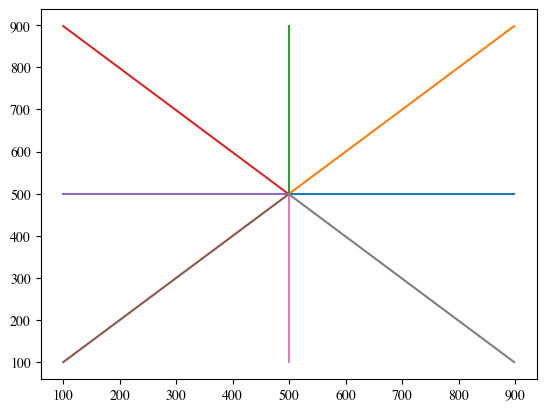

In [291]:
for i in range(8):
    plt.plot(coords[i][0], coords[i][1])

In [292]:
for row in coords:
    print(row)

(array([499, 500, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511,
       512, 513, 514, 515, 516, 517, 518, 519, 520, 521, 522, 523, 524,
       525, 526, 527, 528, 529, 530, 531, 532, 533, 534, 535, 536, 537,
       538, 539, 540, 541, 542, 543, 544, 545, 546, 547, 548, 549, 550,
       551, 552, 553, 554, 555, 556, 557, 558, 559, 560, 561, 562, 563,
       564, 565, 566, 567, 568, 569, 570, 571, 572, 573, 574, 575, 576,
       577, 578, 579, 580, 581, 582, 583, 584, 585, 586, 587, 588, 589,
       590, 591, 592, 593, 594, 595, 596, 597, 598, 599, 600, 601, 602,
       603, 604, 605, 606, 607, 608, 609, 610, 611, 612, 613, 614, 615,
       616, 617, 618, 619, 620, 621, 622, 623, 624, 625, 626, 627, 628,
       629, 630, 631, 632, 633, 634, 635, 636, 637, 638, 639, 640, 641,
       642, 643, 644, 645, 646, 647, 648, 649, 650, 651, 652, 653, 654,
       655, 656, 657, 658, 659, 660, 661, 662, 663, 664, 665, 666, 667,
       668, 669, 670, 671, 672, 673, 674, 675, 676, 677, 678, 6

In [293]:
n_pts = 100

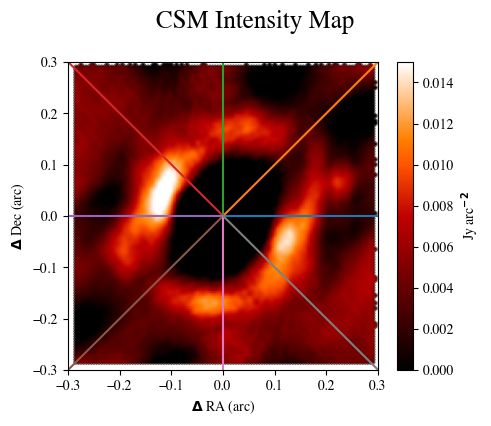

In [294]:
plot2d(data3['csm']['jy_arc2'].value,info3['csm'],suptitle='CSM Intensity Map', vminmax = [0,.015],coords=coords,minn=-.3)

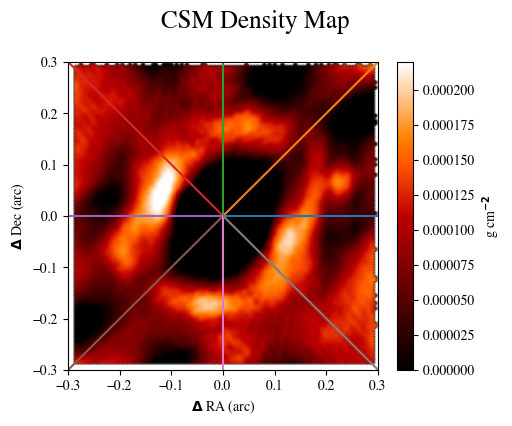

In [295]:
plot2d(data_dens_2d3['csm'].value,info3['csm'],suptitle='CSM Density Map', vminmax = [0,.00022],coords = coords,minn=-.3, dense =True)

# abel

In [296]:
from abel import all_abel, do_abel, plot_1d_abel

In [297]:
line[1,:]

array([ 0.00000000e+00, -6.34648327e-05, -1.88464740e-04, -4.28470348e-04,
       -7.04922652e-04, -8.99547363e-04, -9.20019253e-04, -8.05749583e-04,
       -6.12547062e-04, -4.21652746e-04, -2.73260894e-04, -1.73219636e-04,
       -1.13490538e-04, -8.46485255e-05, -6.30253893e-05, -5.11754339e-05,
       -3.51021081e-05, -2.08067368e-05, -1.21996731e-05, -1.83299118e-07,
        1.11128705e-05,  2.54865901e-05,  4.37134443e-05,  5.78749977e-05,
        6.37517929e-05,  5.90280063e-05,  5.49698299e-05,  5.67429578e-05,
        5.85851536e-05,  5.60965109e-05,  5.37090086e-05,  5.84046375e-05,
        6.54557158e-05,  6.81816135e-05,  6.04176456e-05,  4.75895204e-05,
        3.75295804e-05,  2.72687131e-05,  2.16239755e-05,  1.76905228e-05,
        1.86903165e-05,  1.97981738e-05,  2.45512088e-05,  2.97512463e-05,
        3.70669909e-05,  3.56087742e-05,  3.62507922e-05,  3.83993483e-05,
        4.93150712e-05,  5.50664608e-05,  5.72725108e-05,  6.32703256e-05,
        6.96403095e-05,  

In [298]:
from radial import sm

In [299]:
rs[0]

array([ 705.69256762,  706.40002831,  707.1081954 ,  707.81706676,
        708.52664029,  709.23691387,  709.94788541,  710.65955281,
        711.37191398,  712.08496684,  712.79870931,  713.51313933,
        714.22825483,  714.94405376,  715.66053405,  716.37769368,
        717.0955306 ,  717.81404277,  718.53322818,  719.2530848 ,
        719.97361063,  720.69480364,  721.41666185,  722.13918326,
        722.86236588,  723.58620772,  724.31070681,  725.03586118,
        725.76166887,  726.48812791,  727.21523636,  727.94299227,
        728.6713937 ,  729.40043872,  730.13012539,  730.8604518 ,
        731.59141602,  732.32301616,  733.05525031,  733.78811656,
        734.52161302,  735.25573782,  735.99048907,  736.72586489,
        737.46186342,  738.19848279,  738.93572116,  739.67357665,
        740.41204744,  741.15113169,  741.89082755,  742.6311332 ,
        743.37204682,  744.1135666 ,  744.85569072,  745.59841738,
        746.34174478,  747.08567112,  747.83019463,  748.57531

In [300]:
r_arc = rs*info3['csm']['pix_size_arcsec']
r_pc = sm(168,r_arc).value*u.pc

In [301]:
info3['csm']['median_dens']

<Quantity 8.69052697e-05 g / cm2>

In [302]:
abels = [[0]*n_pts]*8
for i in range(8):
    abels[i] = do_abel(line[i,:],r_pc[0].to(u.cm).value,info3['csm']['median_dens'])

In [303]:
print(r'$\Psi$  = 0')

$\Psi$  = 0


In [304]:
textcolor = 'black'
plt.rcParams['text.color'] = textcolor
# Set default label color to green
plt.rcParams['axes.labelcolor'] = textcolor
# Set default tick color to red
plt.rcParams['xtick.color'] = textcolor
plt.rcParams['ytick.color'] = textcolor

/Users/iman/Documents/cuny_ms/csm_pipeline/everything.py:284: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


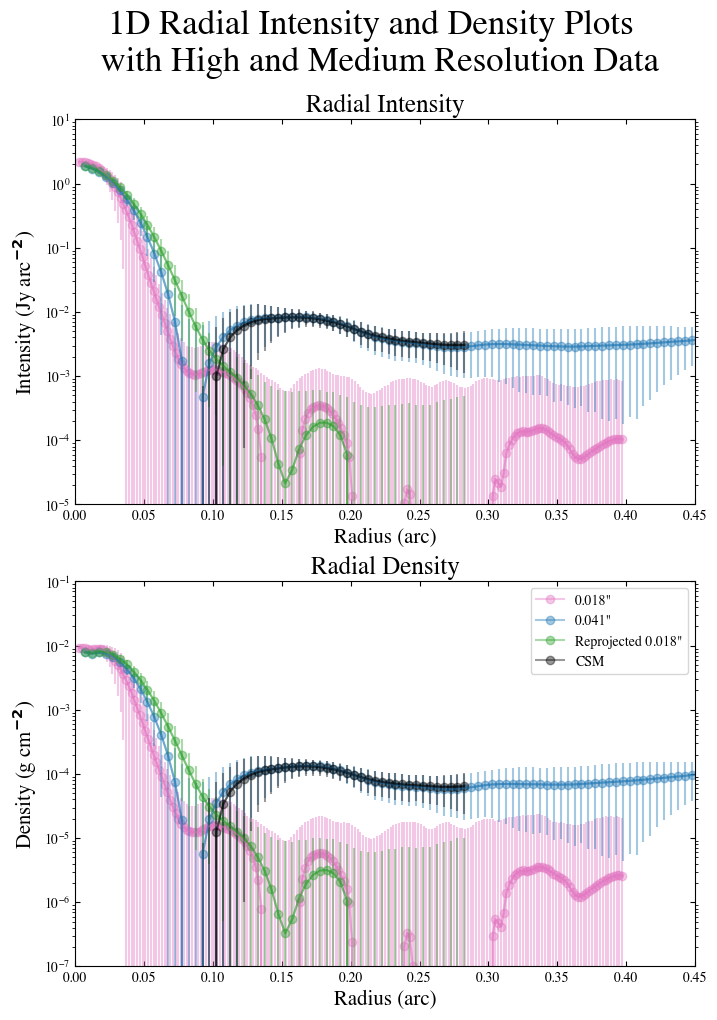

In [305]:
plot_1d(data_1d3, data_dens_1d3,info3,radius3,ax1_ymin=1e-5,ax1_ymax=1e1,ax2_ymin=1e-7,ax2_ymax=1e-1,
        suptitle = "1D Radial Intensity and Density Plots \n with High and Medium Resolution Data")

In [306]:
def plot_1d_abel(data_abel_1d,radius,ax_ymin=1e-2, ax_ymax=1e4,xmin=0,xmax=0.45, suptitle = "1D Abel Transformation (g/cm3)", dent=False):
    '''
    plot 1d density and intensity functions.
    can select plot x and y limits. default values inputted otherwise
    '''


    plt.rcParams["font.family"] = "times"
    fig, ax = plt.subplots(1, 1, figsize = [7,4])
    fig.suptitle(suptitle)

    labels = [r'$\Psi$ = 0',r'$\Psi$ = 0',r'$\Psi$ = 0',r'$\Psi$ = 0',r'$\Psi$ = 0',
             r'$\Psi$ = 0',r'$\Psi$ = 0',r'$\Psi$ = 0']
   
    
    for i in range(8):
            ax.plot(radius[i][:len(data_abel_1d[i])],data_abel_1d[i],'o-',alpha=0.4, label = labels[i])
            #ax.errorbar(radius[title[c]]['arc_1d'],data_1d[title[c]].value,yerr=info[title[c]]['error'].value, c = color[c])

    

    if(dent == True):
         m_e = 9.109e-28 # electron mass in g
         m_p = 1.6726e-24
         plt.axhline(y=(m_e+m_p)*3e8/(0.7), label = "Dent 2025",color = 'black', ls = ':')
         plt.axhline(y=(m_e+m_p)*2e8/(0.7), label = "Judge 1998", color = 'red', ls = '--')
         plt.axhline(y=(m_e+m_p)*1e9/(0.7), label = "Harper 2006", color = 'orange',ls = '-.')



    ax.legend(loc = 'best', bbox_to_anchor=(0.5, 0.5, 0.5, 0.5))
    # ax.set_xlim(xmin,xmax)
    # ax.set_xlim(0,0.45)
    # ax.set_ylim(ax_ymin, ax_ymax)
    # ax.set_ylim(ax_ymin, ax_ymax)

    ax.semilogy()
#     ax.set_title("1-D Density (g/cm3)")
    ax.set_xlabel('Radius (arc)')
    ax.set_ylabel(r'Density (g cm$^{-3}$)')


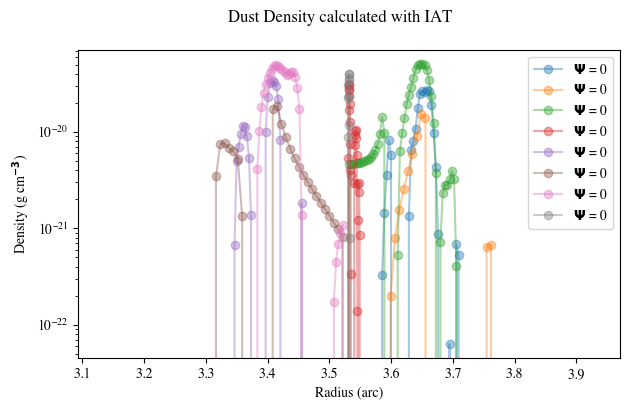

In [307]:
plot_1d_abel(abels,r_arc,ax_ymin=1e-21,ax_ymax=1e-13, suptitle = "Dust Density calculated with IAT")


In [278]:
# H density from Dent et al via webplotdigitizer
data = np.asarray([[1.0801033591731268, 13.018018018018019],
[1.0904392764857884, 12.729729729729732],
[1.103359173126615, 12.423423423423424],
[1.1136950904392768, 12.202702702702704],
[1.245478036175711, 11.774774774774775],
[1.3695090439276487, 11.378378378378379],
[1.4935400516795867, 10.99099099099099],
[1.5813953488372094, 10.702702702702704],
[1.6950904392764858, 10.405405405405405],
[1.7777777777777781, 10.18018018018018],
[1.9069767441860466, 9.99099099099099],
[2.1059431524547803, 9.774774774774775],
[2.30749354005168, 9.608108108108109],
[2.524547803617571, 9.463963963963964],
[2.739018087855297, 9.337837837837839],
[2.9586563307493536, 9.22972972972973],
[3.152454780361757, 9.13963963963964],
[3.4263565891472867, 9.031531531531531],
[3.648578811369509, 8.945945945945946],
[3.8656330749354, 8.873873873873872],
[4.118863049095607, 8.797297297297298],
[4.3824289405684755, 8.72072072072072],
[4.671834625322997, 8.644144144144143],
[4.89405684754522, 8.59009009009009],]).T

xaxis = data[0]*21.5/1000
yaxis = 10**data[1] * 1.6735575e-24 * (1/0.7)

In [309]:
def plot_1d_abel_distribution_rstar(data_abel_1d,info,radius,ax_ymin=1e-2, ax_ymax=1e4,xmin=0,xmax=13, suptitle = "1D Abel Transformation (g/cm3)", dent=False):
    '''
    plot 1d density and intensity functions.
    can select plot x and y limits. default values inputted otherwise
    '''


    plt.rcParams["font.family"] = "times"
    fig, ax = plt.subplots(1, 1, figsize = [7,4])
    fig.suptitle(suptitle)

    title = ['hr','lr','reproj','csm']
    labels = ['{res}"'.format(res = np.round(info['hr']['kspatres'],3)),
             '{res}"'.format(res = np.round(info['lr']['kspatres'],3)),
               'Reprojected {res}"'.format(res = np.round(info['hr']['kspatres'],3)),
                 "CSM"]    
    
    color = ['C6','C0','C2','black']

    for j in range(len(title)):
        print(len(radius[title[j]]['arc_1d'][:len(data_abel_1d[title[j]])]))
        print((data_abel_1d[title[j]]*430).shape)
        ax.fill_between(radius[title[j]]['arc_1d'][:len(data_abel_1d[title[j]])]/0.0295,data_abel_1d[title[j]]+data_abel_1d[title[j]]*430,data_abel_1d[title[j]]+data_abel_1d[title[j]]*1000,alpha=0.4, label = labels[j], color = color[j])
        #ax.plot(radius[title[j]]['arc_1d'][:len(data_abel_1d[title[j]])],data_abel_1d[title[j]]*200,'o-',alpha=0.4, label = labels[j], c = color[j])
            #ax.errorbar(radius[title[c]]['arc_1d'],data_1d[title[c]].value,yerr=info[title[c]]['error'].value, c = color[c])

    

    if(dent == True):
         plt.plot(xaxis/0.0215,yaxis, label = ("Dent et al 2025"),color = 'black')


    ax.axvline(x=1, c = 'red', label = 'R_star = 1', ls = 'dashed')

    ax.legend(loc = 'best', bbox_to_anchor=(0.5, 0.5, 0.5, 0.5))
    ax.set_xlim(xmin,xmax)
    #ax.set_xlim(0,0.45)
    ax.set_ylim(ax_ymin, ax_ymax)
    ax.set_ylim(ax_ymin, ax_ymax)

    ax.semilogy()
#     ax.set_title("1-D Density (g/cm3)")
    ax.set_xlabel(r'Radius [$R_{*}$]')
    ax.set_ylabel(r'Density [g cm$^{-3}$]')


TypeError: list indices must be integers or slices, not str

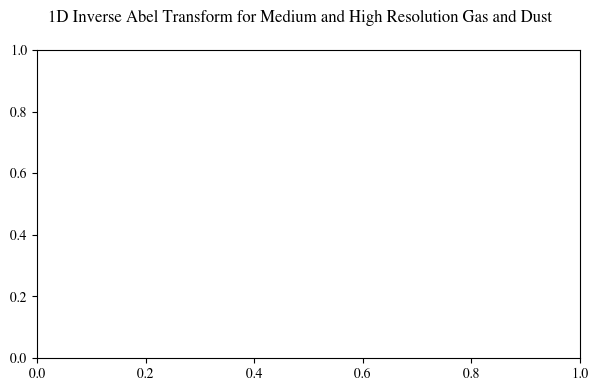

In [310]:
plot_1d_abel_distribution_rstar(abels,info3,radius3,ax_ymin=1e-18,ax_ymax=1e-10, suptitle = "1D Inverse Abel Transform for Medium and High Resolution Gas and Dust" ,dent = True)